<a href="https://colab.research.google.com/github/Bee-Ene/Diachronic-Text-Analysis/blob/main/Semantic_Drift.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Diachronic Text Analysis: Studying

---

Language Evolution Over Time

This analyzes how word meanings change over time using word embeddings trained on different time periods. Embedding spaces were aligned and measurement of semantic drift using similarity, vector displacement, and nearest neighbors.


The goal of this project is to analyze semantic evolution across time using NLP techniques. We trained separate word embedding models for different temporal periods and aligned their vector spaces to measure semantic drift quantitatively and visually.


Diachronic Analysis: How language changes over time.

The project is based on the distributional hypothesis: words used in similar contexts tend to have similar meanings.

NB: Since AG News does not contain explicit timestamps, synthetic temporal labels were generated to simulate diachronic conditions.


Lowercasing: normalize vocabulary

Regex cleaning: remove punctuation/noise

Tokenization: split text into words

Lemmatization: reduce inflected forms

Word2Vec: Learn vectors by predicting contextual relationships. It works because Because semantic similarity emerges from contextual co-occurrence statistics learned during prediction optimization.

Different Word2Vec models produce different coordinate systems. So vectors cannot be directly compared. Orthogonal Procrustes alignment.

Cosine similarity:orientation.
Vector shift: displacement magnitude.
Nearest words indicate semantic context. Because semantic drift becomes interpretable linguistically


high cosine similarity,moderate vector displacement.
core semantics remain relatively stable,contextual usage evolves gradually.
Semantic evolution appears gradual rather than abrupt, suggesting contextual drift rather than complete semantic replacement.

In summary:
modeled semantic evolution,
aligned temporal embedding spaces,
quantified semantic drift,
visualized linguistic change.

In [ ]:
#Install dependencies
#!pip install datasets gensim nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 36.8 MB/s eta 0:00:00


In [ ]:
#Imports
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from datasets import load_dataset
from nltk.stem import WordNetLemmatizer
from gensim.models import Word2Vec
from scipy.linalg import orthogonal_procrustes
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
# Load dataset
dataset = load_dataset("ag_news")
df = pd.DataFrame(dataset["train"])

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [ ]:
# Simulate time periods
np.random.seed(42)
df["year"] = np.random.choice(range(1900, 2020), size=len(df))

def get_decade(year):
  return (year // 10) * 10

df["decade"] = df["year"].apply(get_decade)

In [ ]:
# Build corpus by period
data_by_period = {}

for decade, group in df.groupby("decade"):
  sentences = []
  for text in group["text"]:
    tokens = text.lower().split()
    sentences.append(tokens)
  data_by_period[str(decade)] = sentences
print("Time periods:", list(data_by_period.keys()))

Time periods: ['1900', '1910', '1920', '1930', '1940', '1950', '1960', '1970', '1980', '1990', '2000', '2010']


In [ ]:
#Preprocessing
lemmatizer = WordNetLemmatizer()

def preprocess(sentence):
  processed = []
  for w in sentence:
     w = re.sub(r"[^a-z]", "", w)
     if w != "":
      processed.append(lemmatizer.lemmatize(w))
  return processed

sentences_by_period = {}

for period, sentences in data_by_period.items():
  sentences_by_period[period] = [preprocess(s) for s in sentences]

In [ ]:
# Train Word2Vec models
models = {}

for period, sentences in sentences_by_period.items():
  print(f"Training model for period {period}")

  model = Word2Vec(
      sentences=sentences,
      vector_size=50,
      window=3,
      min_count=2,
      workers=2
  )
  models[period] = model

Training model for period 1900
Training model for period 1910
Training model for period 1920
Training model for period 1930
Training model for period 1940
Training model for period 1950
Training model for period 1960
Training model for period 1970
Training model for period 1980
Training model for period 1990
Training model for period 2000
Training model for period 2010


In [ ]:
# Alignment (Procrustes)
def align_models(base_model, target_model):
  common_vocab = list(
      set(base_model.wv.index_to_key) & set(target_model.wv.index_to_key)
  )
  base_vecs = np.array([base_model.wv[w] for w in common_vocab])
  target_vecs = np.array([target_model.wv[w] for w in common_vocab])

  R, _ = orthogonal_procrustes(target_vecs, base_vecs)

  aligned = {}
  for word in target_model.wv.index_to_key:
    aligned[word] = target_model.wv[word].dot(R)
  return aligned

In [ ]:
# Align all to earliest period
periods = sorted(models.keys())
base_period = periods[0]
base_model = models[base_period]

aligned_embeddings = {base_period: base_model.wv}

for period in periods[1:]:
  aligned_embeddings[period] = align_models(base_model, models[period])

print("Alignment completed")

Alignment completed


In [ ]:
#Drift metrics
def cosine_similarity(v1, v2):
  return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

def vector_shift(v1, v2):
  return np.linalg.norm(v1 - v2)

In [ ]:
#Drift analysis for selected words
words = ["government", "market", "technology", "health"]

for word in words:
  print(f"\n WORD: {word}")

  vectors = []

  for period in sorted(aligned_embeddings.keys()):
    emb = aligned_embeddings[period]
    if word in emb:
      vectors.append((period, emb[word]))

  #vectors = sorted(vectors, key=lambda x: x[0])

  for i in range(len(vectors)-1):
    p1, v1 = vectors[i]
    p2, v2 = vectors[i+1]

    print(f"{p1} -> {p2}")
    print("Cosine similarity:", cosine_similarity(v1, v2))
    print("Vector shift:", vector_shift(v1, v2))
    print()


 WORD: government
1900 -> 1910
Cosine similarity: 0.97948086
Vector shift: 0.95517737

1910 -> 1920
Cosine similarity: 0.97598755
Vector shift: 0.99336106

1920 -> 1930
Cosine similarity: 0.97379786
Vector shift: 1.0383831

1930 -> 1940
Cosine similarity: 0.9815929
Vector shift: 0.9555755

1940 -> 1950
Cosine similarity: 0.96080923
Vector shift: 1.3316429

1950 -> 1960
Cosine similarity: 0.974885
Vector shift: 1.0581825

1960 -> 1970
Cosine similarity: 0.98689467
Vector shift: 0.73949057

1970 -> 1980
Cosine similarity: 0.97423476
Vector shift: 1.0324438

1980 -> 1990
Cosine similarity: 0.97955686
Vector shift: 0.9389928

1990 -> 2000
Cosine similarity: 0.97335684
Vector shift: 1.1100107

2000 -> 2010
Cosine similarity: 0.9836526
Vector shift: 0.87465876


 WORD: market
1900 -> 1910
Cosine similarity: 0.9892805
Vector shift: 0.7152684

1910 -> 1920
Cosine similarity: 0.98896956
Vector shift: 0.7408935

1920 -> 1930
Cosine similarity: 0.9919425
Vector shift: 0.6185537

1930 -> 1940
Cos

In [ ]:
#PCA visualization
def plot_pca(word):
  vectors = []
  labels = []

  for period in sorted(aligned_embeddings.keys()):
    emb = aligned_embeddings[period]
    if word in emb:
      vectors.append(emb[word])
      labels.append(period)

  if len(vectors) < 2:
    return

  vectors = np.array(vectors) # Convert list of vectors to a NumPy array

  pca = PCA(n_components=2)
  reduced = pca.fit_transform(vectors)

  plt.figure()
  plt.scatter(reduced[:,0], reduced[:,1])

  #trajectory
  plt.plot(reduced[:,0], reduced[:,1])

  for i, label in enumerate(labels):
    plt.text(reduced[i,0], reduced[i,1], label)

  plt.title(f"PCA Semantic Drift: {word}")
  plt.show()

In [ ]:
# t-SNE visualization
def plot_tsne(word):
  vectors = []
  labels = []

  for period in sorted(aligned_embeddings.keys()):
    emb = aligned_embeddings[period]
    if word in emb:
      vectors.append(emb[word])
      labels.append(period)

  if len(vectors) < 2:
    print(f'Not enough data for {word}')
    return

  vectors = np.array(vectors) # Convert list of vectors to a NumPy array

  tsne = TSNE(n_components=2, perplexity=5, random_state=42, max_iter=1000)
  reduced = tsne.fit_transform(vectors)

  plt.figure()
  plt.scatter(reduced[:,0], reduced[:,1])

  for i, label in enumerate(labels):
    plt.text(reduced[i,0], reduced[i,1], label)

  plt.title(f"t-SNE Semantic Drift: {word}")
  plt.show()

In [ ]:
#Neighbors
def print_neighbors(word):
  print(f"\n Nearest Neighbors for: {word}")

  for period in sorted(models.keys()):
    model = models[period]

    print(f"\nPeriod: {period}")

    if word in model.wv:
      neighbors = model.wv.most_similar(word, topn=5)
      for n, score in neighbors:
        print(f"{n} ({score:.3f})")
    else:
      print(f"Word not found")

#run
for w in ['government', 'market', 'technology', 'health']:
  print_neighbors(w)


 Nearest Neighbors for: government

Period: 1900
federal (0.947)
spokeswoman (0.945)
agency (0.945)
report (0.938)
department (0.937)

Period: 1910
federal (0.956)
agency (0.955)
spokesman (0.948)
department (0.945)
ministry (0.942)

Period: 1920
witness (0.965)
department (0.963)
spokesman (0.959)
statement (0.949)
spokeswoman (0.944)

Period: 1930
federal (0.971)
judge (0.964)
agency (0.959)
commission (0.959)
ministry (0.959)

Period: 1940
spokesman (0.964)
department (0.961)
interview (0.950)
court (0.948)
witness (0.948)

Period: 1950
department (0.932)
court (0.929)
spokesman (0.923)
witness (0.917)
military (0.906)

Period: 1960
agency (0.961)
ministry (0.959)
court (0.956)
interview (0.955)
newspaper (0.953)

Period: 1970
department (0.970)
agency (0.954)
federal (0.949)
court (0.945)
medic (0.941)

Period: 1980
spokesman (0.940)
department (0.939)
official (0.931)
federal (0.926)
ministry (0.923)

Period: 1990
group (0.946)
agency (0.943)
statement (0.935)
union (0.934)
spoke

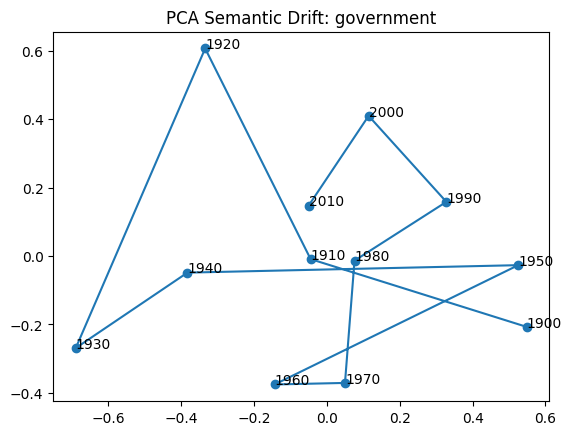

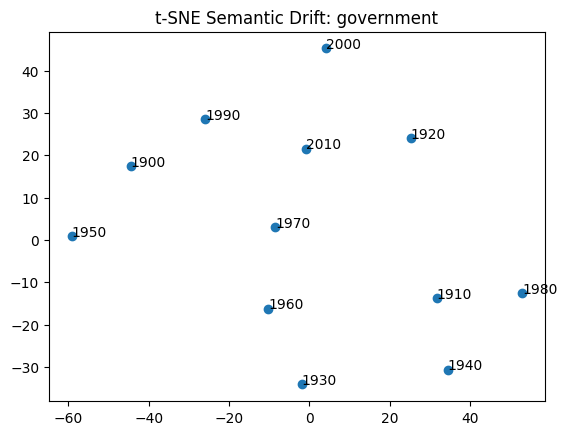

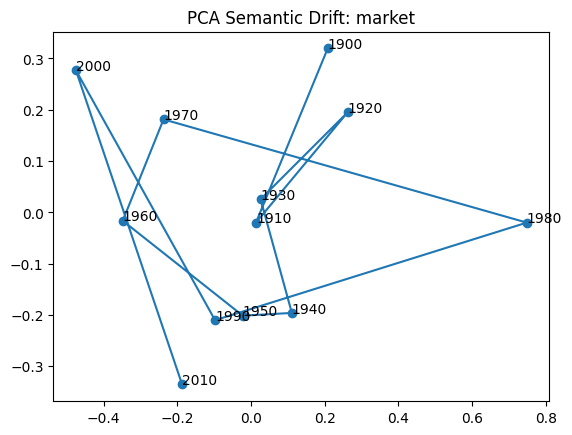

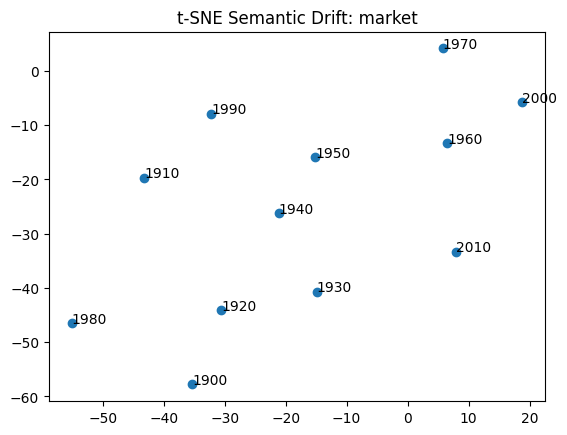

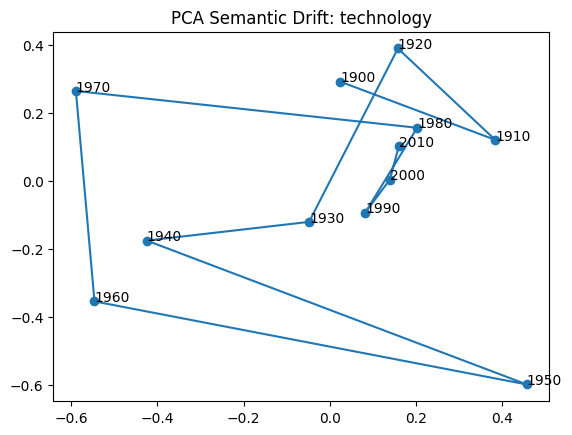

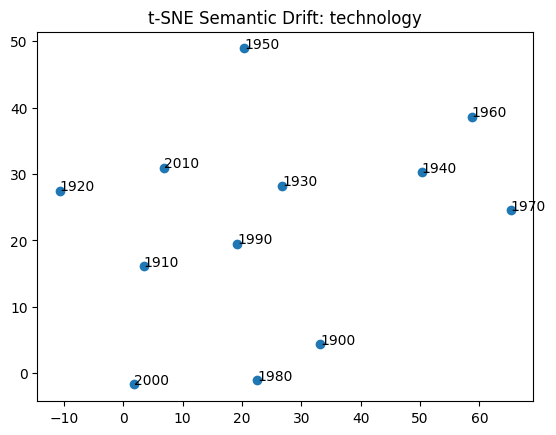

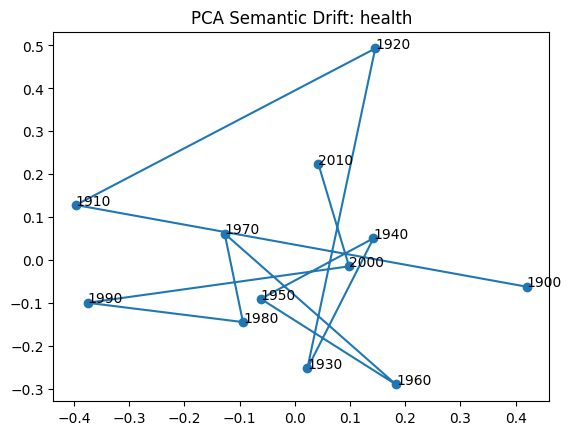

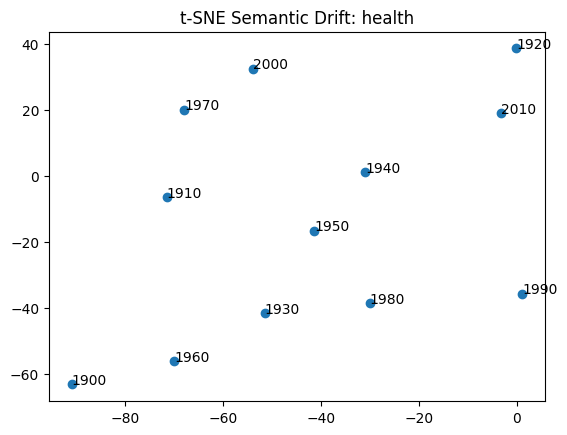

In [ ]:
#Run visualizations
for w in words:
  plot_pca(w)
  plot_tsne(w)

In [ ]:
#Check
word = 'technology'

for period in sorted(aligned_embeddings.keys()):
  emb = aligned_embeddings[period]
  if word in emb:
    print(period, emb[word][:5])

1900 [-0.14976835  0.0514378  -0.2091045   0.41436702 -0.18731275]
1910 [-0.10707141 -0.02199203 -0.26837164  0.4910646  -0.21743344]
1920 [-0.20205988 -0.12036928 -0.19498923  0.43392515 -0.08005464]
1930 [-0.06180981  0.0943969  -0.07936302  0.5665258  -0.14515716]
1940 [-0.09909461  0.108243   -0.08821701  0.52029103 -0.27459323]
1950 [ 0.02285114  0.11069724 -0.2916019   0.41821718 -0.17441434]
1960 [ 0.02688068  0.14698568 -0.10290454  0.66741246 -0.21645918]
1970 [-0.0939772   0.0894163  -0.0577625   0.532169   -0.21542792]
1980 [-0.04228355  0.01515254 -0.19204779  0.35380906 -0.14927994]
1990 [-0.06273942  0.03067609 -0.18658362  0.50894856 -0.16896306]
2000 [ 0.05960137 -0.06248161 -0.30091792  0.44456574 -0.20835452]
2010 [-0.3464016  -0.08104141 -0.17933494  0.5572529  -0.12113562]
